Liberías y paquetes

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Lectura de datos

In [5]:
sales = pd.read_csv('sales_data.csv', parse_dates=['Date'])
sales.head()


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


Promedio de la edad de los clientes

In [6]:
sales['Customer_Age'].mean()

35.91921157861212

KDE densidad 

<Axes: ylabel='Density'>

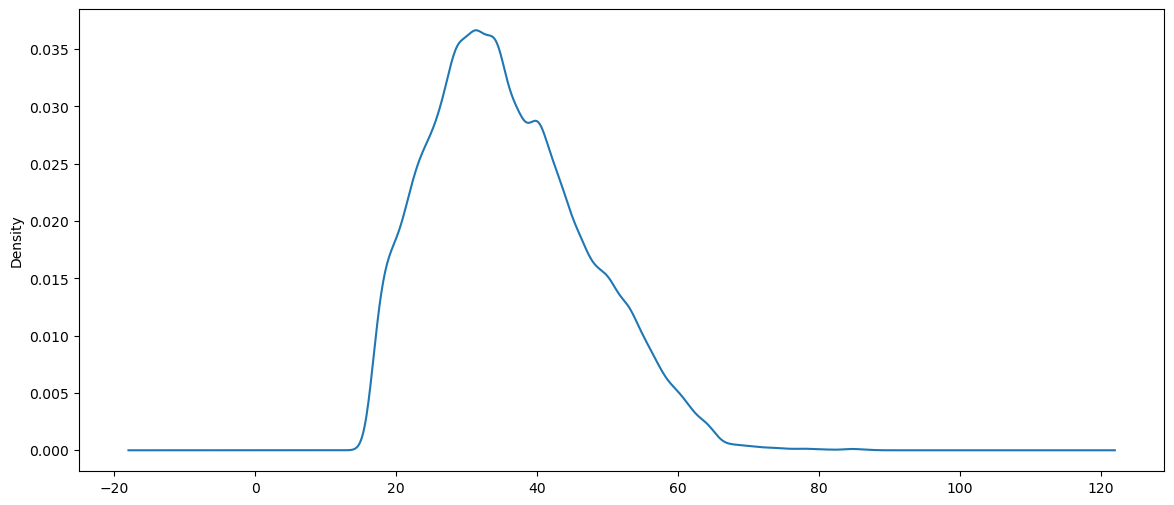

In [ ]:
sales['Customer_Age'].plot(kind='kde', figsize=(14,6)) #14 inches wide, 6 inches tall

<Axes: >

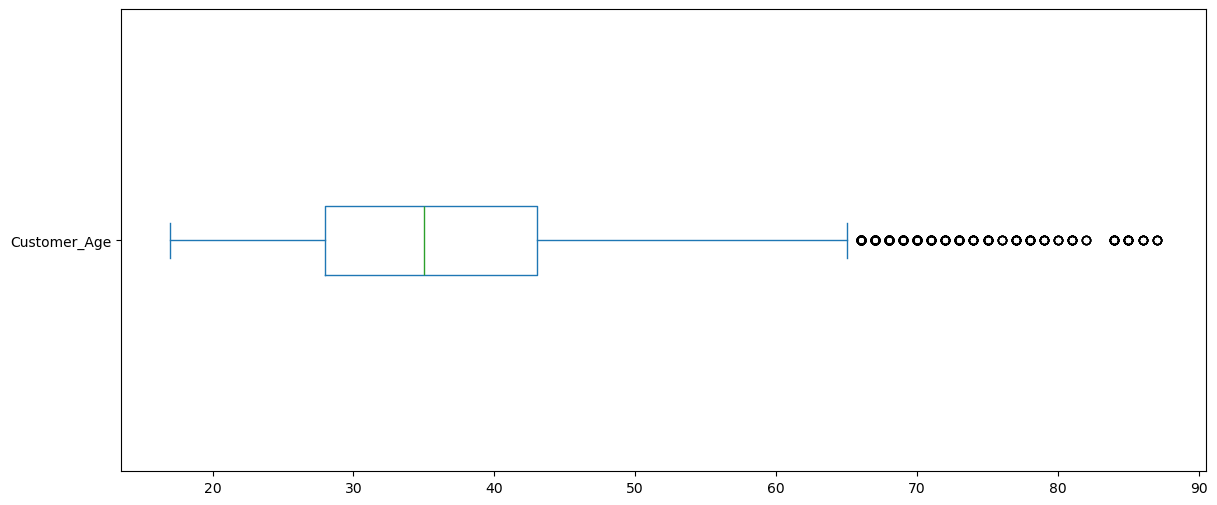

In [ ]:
sales['Customer_Age'].plot(kind='box', vert=False, figsize=(14,6))

# Promedio y distribución de Order_Quality

In [11]:
sales['Order_Quantity'].mean()


11.901659648253654

<Axes: ylabel='Frequency'>

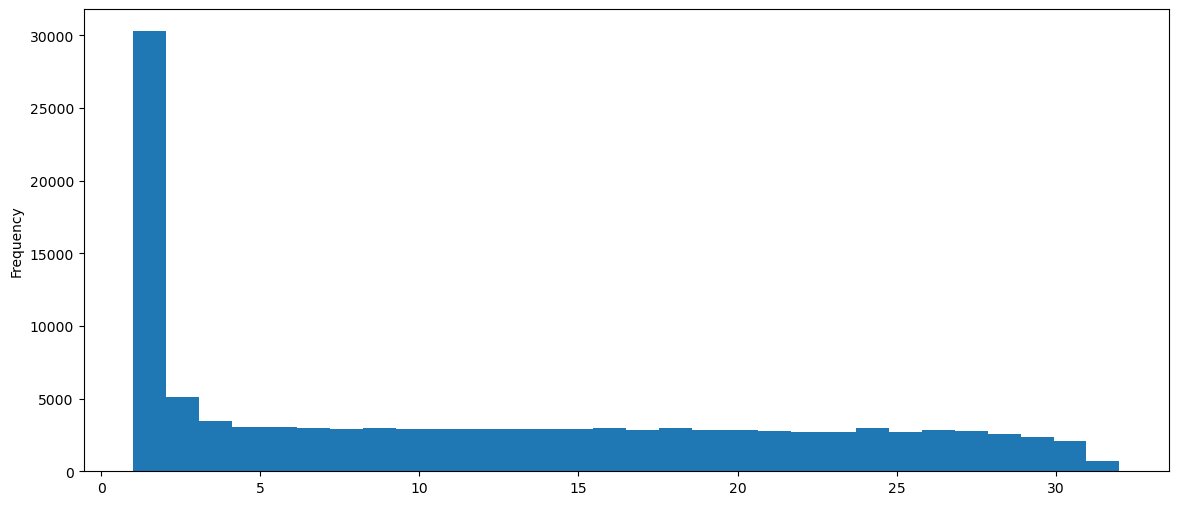

In [12]:
sales['Order_Quantity'].plot(kind='hist', figsize=(14,6), bins=30) 

<Axes: >

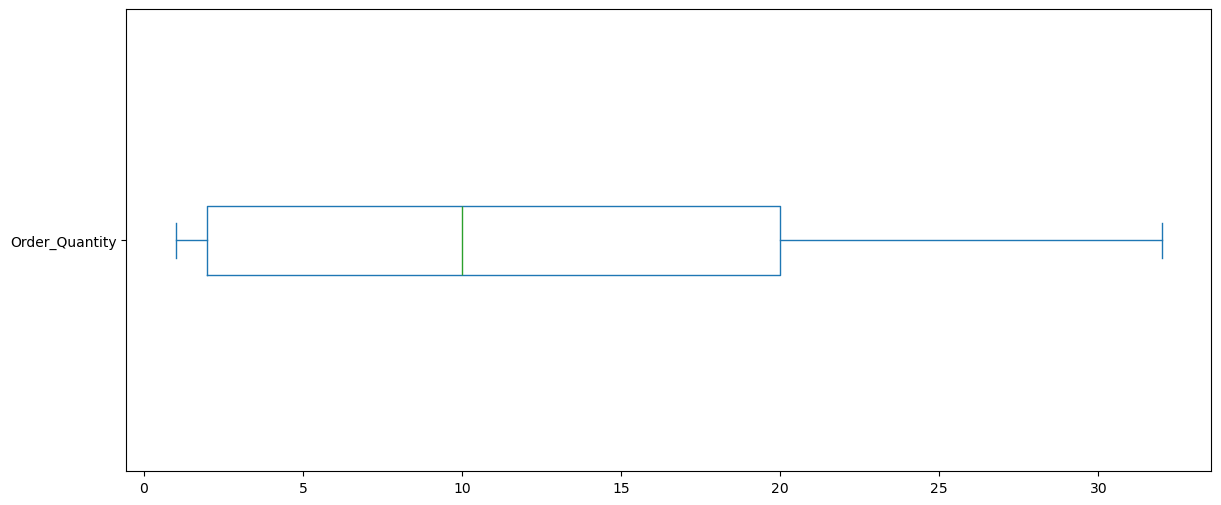

In [15]:
sales['Order_Quantity'].plot(kind='box', vert=False, figsize=(14,6))

# Ventas anuales


In [17]:
sales['Year'].value_counts()

Year
2014    29398
2016    29398
2013    24443
2015    24443
2012     2677
2011     2677
Name: count, dtype: int64

<Axes: ylabel='count'>

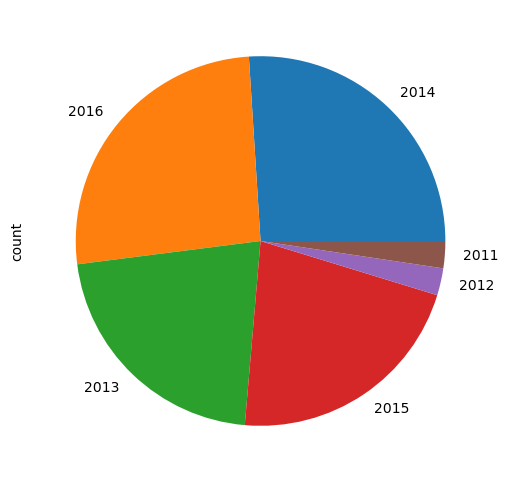

In [19]:
sales['Year'].value_counts().plot(kind='pie', figsize=(6,6))

# Ventas mensuales

In [20]:
sales.columns

Index(['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group',
       'Customer_Gender', 'Country', 'State', 'Product_Category',
       'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price',
       'Profit', 'Cost', 'Revenue'],
      dtype='object')

<Axes: xlabel='Month'>

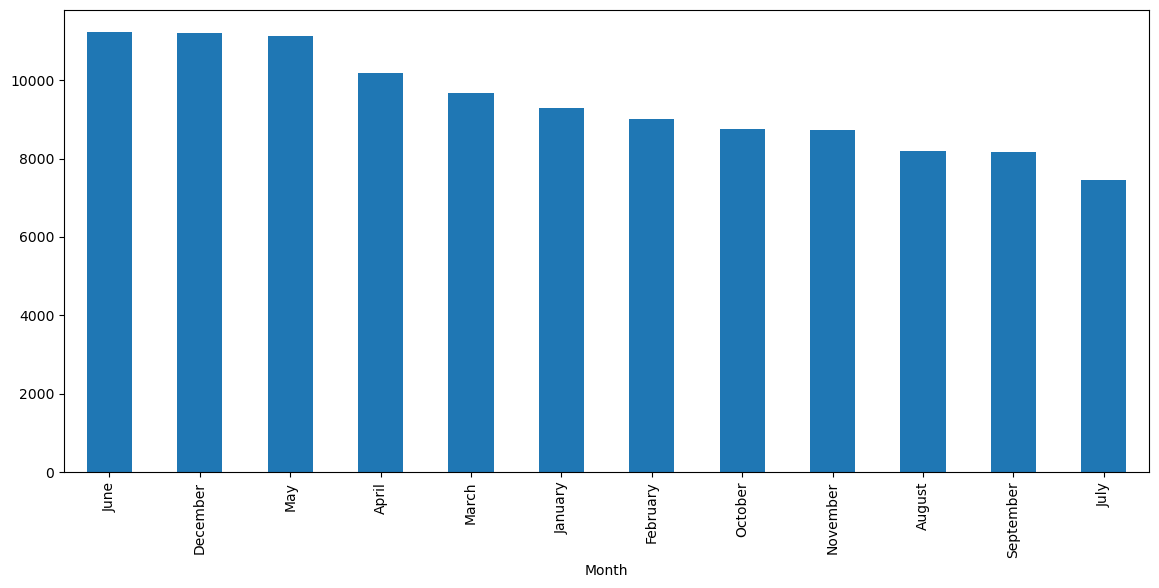

In [21]:
sales['Month'].value_counts().plot(kind='bar', figsize=(14,6))

# Cantidad de ventas por país

<Axes: xlabel='Country'>

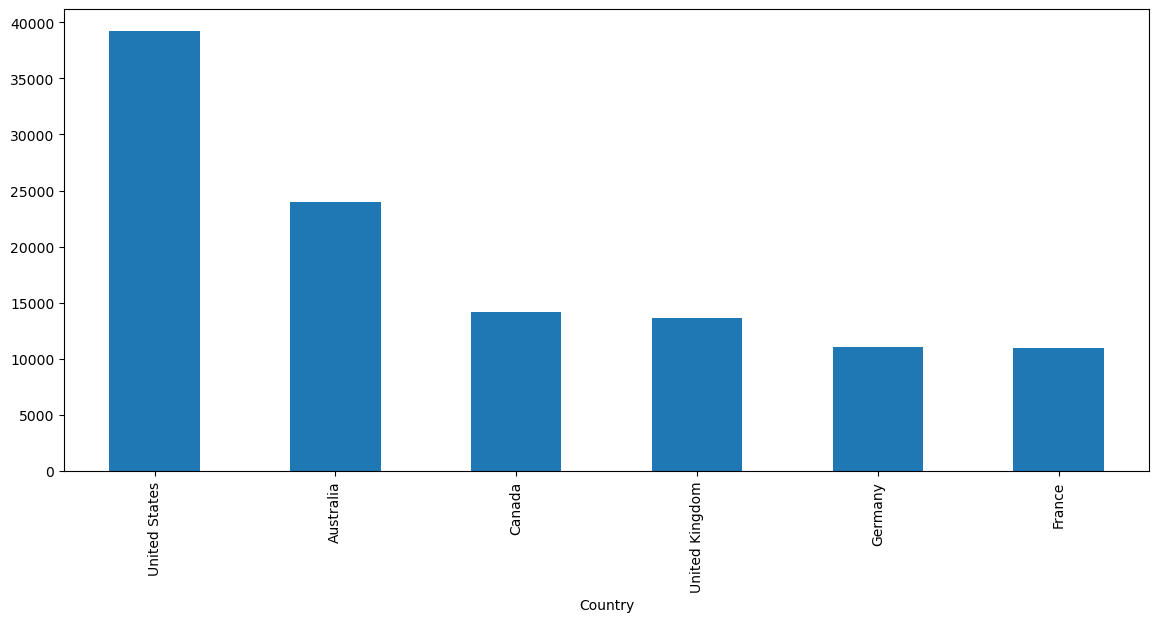

In [24]:
sales['Country'].value_counts().plot(kind='bar', figsize=(14,6))

In [23]:
sales['Country'].value_counts().head(1)

Country
United States    39206
Name: count, dtype: int64

# Lista por producto unico vendido

In [29]:
sales['Product'].unique()


array(['Hitch Rack - 4-Bike', 'All-Purpose Bike Stand',
       'Mountain Bottle Cage', 'Water Bottle - 30 oz.',
       'Road Bottle Cage', 'AWC Logo Cap', 'Bike Wash - Dissolver',
       'Fender Set - Mountain', 'Half-Finger Gloves, L',
       'Half-Finger Gloves, M', 'Half-Finger Gloves, S',
       'Sport-100 Helmet, Black', 'Sport-100 Helmet, Red',
       'Sport-100 Helmet, Blue', 'Hydration Pack - 70 oz.',
       'Short-Sleeve Classic Jersey, XL',
       'Short-Sleeve Classic Jersey, L', 'Short-Sleeve Classic Jersey, M',
       'Short-Sleeve Classic Jersey, S', 'Long-Sleeve Logo Jersey, M',
       'Long-Sleeve Logo Jersey, XL', 'Long-Sleeve Logo Jersey, L',
       'Long-Sleeve Logo Jersey, S', 'Mountain-100 Silver, 38',
       'Mountain-100 Silver, 44', 'Mountain-100 Black, 48',
       'Mountain-100 Silver, 48', 'Mountain-100 Black, 38',
       'Mountain-200 Silver, 38', 'Mountain-100 Black, 44',
       'Mountain-100 Silver, 42', 'Mountain-200 Black, 46',
       'Mountain-200 Silver

<Axes: xlabel='Product'>

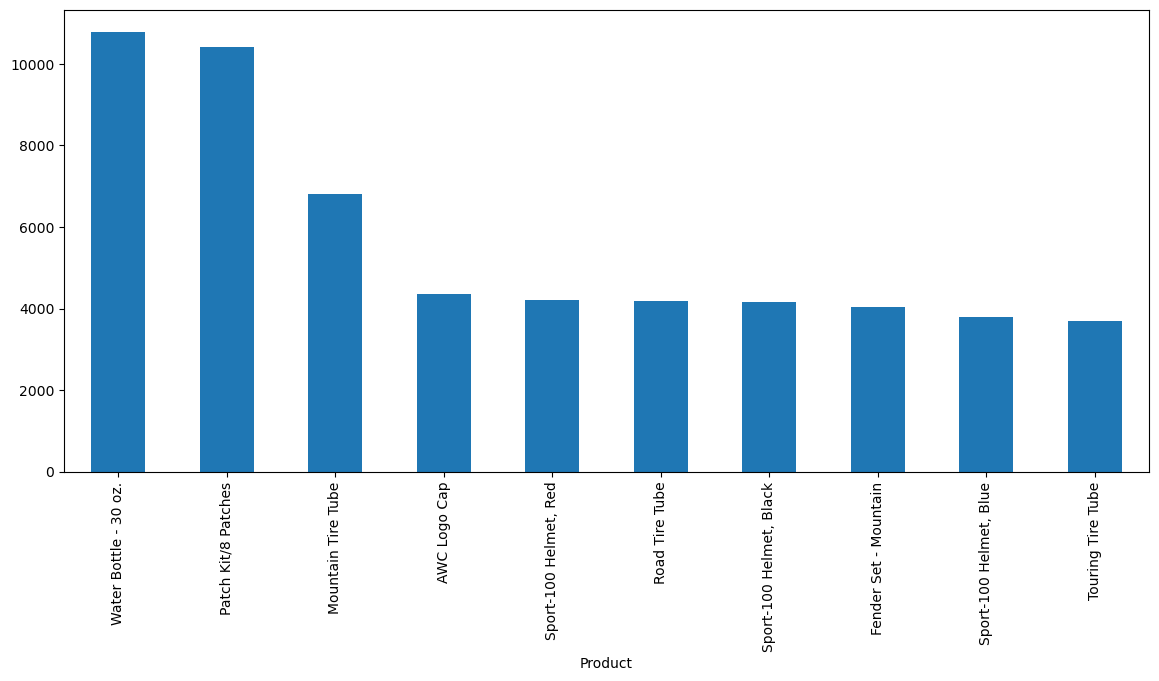

In [30]:
sales['Product'].value_counts().head(10).plot(kind='bar', figsize=(14,6))

# Unit_Cost vs Unit_Price 


<Axes: xlabel='Unit_Cost', ylabel='Unit_Price'>

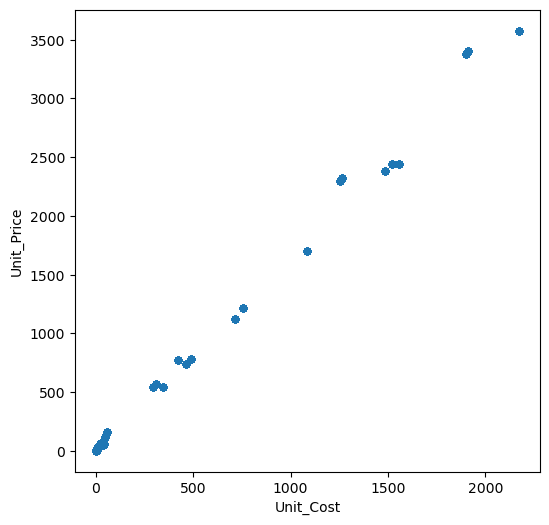

In [32]:
sales.plot(kind='scatter', x='Unit_Cost', y='Unit_Price', figsize=(6,6))


# Relación entre el profit con respecto al país

<Axes: title={'center': 'Profit'}, xlabel='[Country]'>

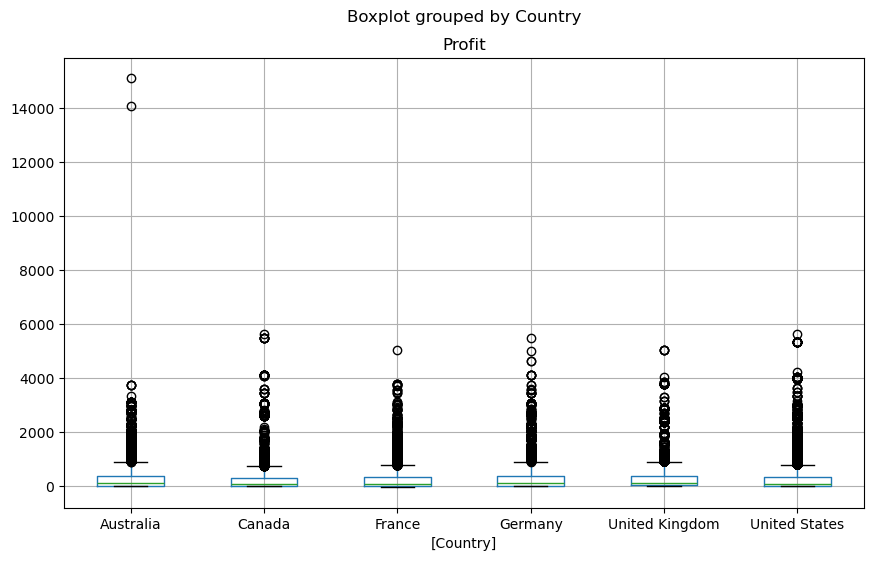

In [35]:
sales[['Profit', 'Country']].boxplot(by='Country', figsize=(10,6))

# Relación entre la edad del cliente y el país

<Axes: title={'center': 'Customer_Age'}, xlabel='[Country]'>

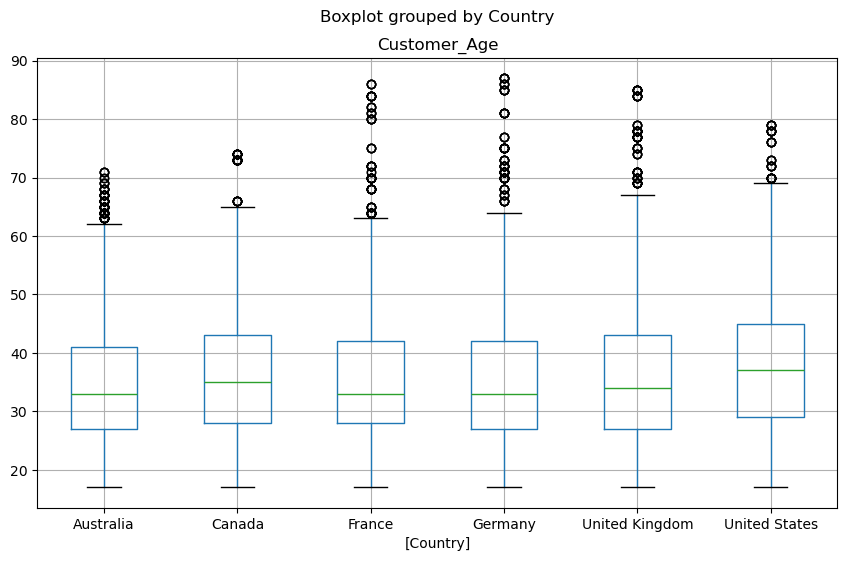

In [36]:
sales[['Customer_Age', 'Country']].boxplot(by='Country', figsize=(10,6))

Nueva columna para Año, Mes, Día

In [37]:
sales['Calculated_Date'] = sales[['Year', 'Month', 'Day']].apply(lambda x: '{}-{}-{}'.format(x[0], x[1], x[2]), axis=1)
sales['Calculated_Date'].head()

/var/folders/2r/ht33x8dn3qj7nxtm10ns69p80000gn/T/ipykernel_2082/945241705.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sales['Calculated_Date'] = sales[['Year', 'Month', 'Day']].apply(lambda x: '{}-{}-{}'.format(x[0], x[1], x[2]), axis=1)


0    2013-November-26
1    2015-November-26
2       2014-March-23
3       2016-March-23
4         2014-May-15
Name: Calculated_Date, dtype: object